# EDA Exploration

This notebook is the trial-and-error workspace for Part II (see `CONVENTIONS.md`). Findings are moved, cleaned up, to `EDA_report.md` once the exploration is done.

## Contents

- **Step A-B:** initial diagnostics (dtypes, duplicates, nulls) and a null-overlap check across the 4 columns with missing values.
- **Step C:** missingness-mechanism classification (MCAR/MAR/MNAR) per column, with the evidence behind each call.
- **Step D-F:** numeric distributions, categorical frequencies, and IQR outlier detection.
- **Step 4:** categorical variables vs. the target (`Weather`, `Traffic_Level`, `Time_of_Day`, `Vehicle_Type`).
- **Step 5:** correlation matrix across the numeric variables and the target.

Findings are consolidated in `EDA_report.md`.

## Step A: initial diagnostic — dtypes, duplicates, nulls (lightweight)

A quick first look at the raw dataset before any deeper analysis: shape and column types, duplicate rows, and a null-count table. No imputation, target comparisons, or plots yet.

In [1]:
import pandas as pd

df = pd.read_csv("../data/Food_Delivery_Times.csv")
print(f"Shape: {df.shape}")
df.dtypes

Shape: (1000, 9)


Order_ID                    int64
Distance_km               float64
Weather                       str
Traffic_Level                 str
Time_of_Day                   str
Vehicle_Type                  str
Preparation_Time_min        int64
Courier_Experience_yrs    float64
Delivery_Time_min           int64
dtype: object

In [2]:
n_duplicates = df.duplicated().sum()
print(f"Duplicate rows: {n_duplicates}")

Duplicate rows: 0


In [3]:
null_summary = pd.DataFrame({
    "n_nulls": df.isnull().sum(),
    "pct_nulls": (df.isnull().sum() / len(df) * 100).round(2),
})
null_summary

,n_nulls,pct_nulls
Order_ID,0,0.0
Distance_km,0,0.0
Weather,30,3.0
Traffic_Level,30,3.0
Time_of_Day,30,3.0
Vehicle_Type,0,0.0
Preparation_Time_min,0,0.0
Courier_Experience_yrs,30,3.0
Delivery_Time_min,0,0.0


## Step B: null overlap check

`Weather`, `Traffic_Level`, `Time_of_Day`, and `Courier_Experience_yrs` each have exactly 30 nulls. This checks whether that is the same 30 rows across all four columns, or unrelated rows that coincidentally add up to the same count.

In [4]:
null_cols = ["Weather", "Traffic_Level", "Time_of_Day", "Courier_Experience_yrs"]

n_any_null = df[null_cols].isnull().any(axis=1).sum()
n_all_null = df[null_cols].isnull().all(axis=1).sum()

print(f"Rows with a null in at least one of the 4 columns: {n_any_null}")
print(f"Rows with a null in all 4 columns simultaneously: {n_all_null}")

Rows with a null in at least one of the 4 columns: 117
Rows with a null in all 4 columns simultaneously: 0


In [5]:
n_null_per_row = df[null_cols].isnull().sum(axis=1)
n_null_per_row[n_null_per_row > 0].value_counts().sort_index().rename("n_rows").to_frame()

,n_rows
1,114
2,3


## Step C: missingness mechanism per column (MCAR / MAR / MNAR)

For each of the 4 columns with nulls, this checks two kinds of evidence separately: whether rows with a null differ in `Delivery_Time_min` (the target) from rows without one, and whether the null rate itself concentrates in 1-2 candidate variables rather than being spread evenly. Category sizes are large enough here (roughly 85-500 rows per category) that a null-rate difference of a couple of percentage points is unlikely to be pure noise, though this is a descriptive check, not a formal statistical test.

### `Weather`

In [6]:
col = "Weather"
df.groupby(df[col].isnull())["Delivery_Time_min"].agg(["mean", "median", "std", "count"])

,mean,median,std,count
Weather,,,,
False,56.810309,56.0,22.034664,970
True,54.200000,53.5,23.462957,30


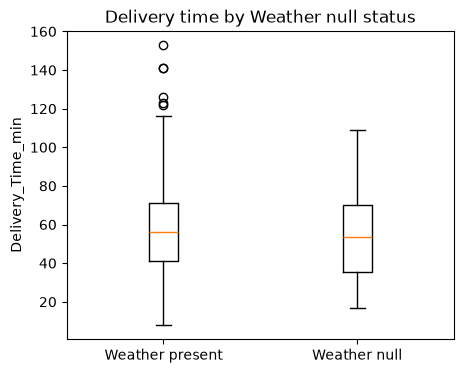

In [7]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(5, 4))
ax.boxplot(
    [df.loc[df[col].notnull(), "Delivery_Time_min"], df.loc[df[col].isnull(), "Delivery_Time_min"]],
    tick_labels=[f"{col} present", f"{col} null"],
)
ax.set_ylabel("Delivery_Time_min")
ax.set_title(f"Delivery time by {col} null status")
plt.show()

In [8]:
pd.DataFrame({
    "null_rate_by_Traffic_Level": df.groupby("Traffic_Level")[col].apply(lambda s: s.isnull().mean()),
}).round(3), pd.DataFrame({
    "null_rate_by_Vehicle_Type": df.groupby("Vehicle_Type")[col].apply(lambda s: s.isnull().mean()),
}).round(3)

(               null_rate_by_Traffic_Level
 Traffic_Level                            
 High                                0.030
 Low                                 0.023
 Medium                              0.038,
               null_rate_by_Vehicle_Type
 Vehicle_Type                           
 Bike                              0.018
 Car                               0.046
 Scooter                           0.040)

**Classification: MCAR.** `Delivery_Time_min` is nearly identical between the two groups (54.2 vs 56.8 min, well within one standard deviation), and the null rate barely moves across `Traffic_Level` (2.3-3.8%) or `Vehicle_Type` (1.8-4.6%) — no candidate shows a consistent, sizeable split. The missingness looks unrelated to any observed variable checked here.

### `Traffic_Level`

In [9]:
col = "Traffic_Level"
df.groupby(df[col].isnull())["Delivery_Time_min"].agg(["mean", "median", "std", "count"])

,mean,median,std,count
Traffic_Level,,,,
False,56.567010,55.0,21.944769,970
True,62.066667,60.0,25.672921,30


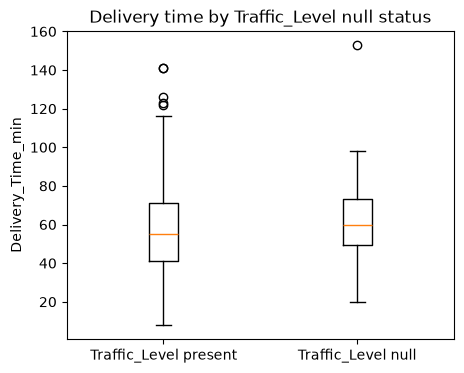

In [10]:
fig, ax = plt.subplots(figsize=(5, 4))
ax.boxplot(
    [df.loc[df[col].notnull(), "Delivery_Time_min"], df.loc[df[col].isnull(), "Delivery_Time_min"]],
    tick_labels=[f"{col} present", f"{col} null"],
)
ax.set_ylabel("Delivery_Time_min")
ax.set_title(f"Delivery time by {col} null status")
plt.show()

In [11]:
pd.DataFrame({
    "null_rate_by_Vehicle_Type": df.groupby("Vehicle_Type")[col].apply(lambda s: s.isnull().mean()),
}).round(3), pd.DataFrame({
    "null_rate_by_Weather": df.groupby("Weather")[col].apply(lambda s: s.isnull().mean()),
}).round(3)

(              null_rate_by_Vehicle_Type
 Vehicle_Type                           
 Bike                              0.020
 Car                               0.036
 Scooter                           0.043,
          null_rate_by_Weather
 Weather                      
 Clear                   0.036
 Foggy                   0.010
 Rainy                   0.029
 Snowy                   0.031
 Windy                   0.031)

**Classification: MAR (leaning).** Rows with a null `Traffic_Level` average 62.1 min vs. 56.6 min for the rest — a real gap, and one tied to `Delivery_Time_min`, an observed variable, which is the textbook signature of MAR rather than MCAR. `Vehicle_Type` reinforces this: the null rate roughly doubles from `Bike` (2.0%) to `Scooter` (4.3%). MNAR cannot be ruled out (e.g. traffic readings failing specifically during severe congestion), but there is no way to test that directly since the true missing values are unobserved — the evidence in hand only supports dependence on observed variables.

### `Time_of_Day`

In [12]:
col = "Time_of_Day"
df.groupby(df[col].isnull())["Delivery_Time_min"].agg(["mean", "median", "std", "count"])

,mean,median,std,count
Time_of_Day,,,,
False,56.440206,55.0,21.572424,970
True,66.166667,62.5,33.703661,30


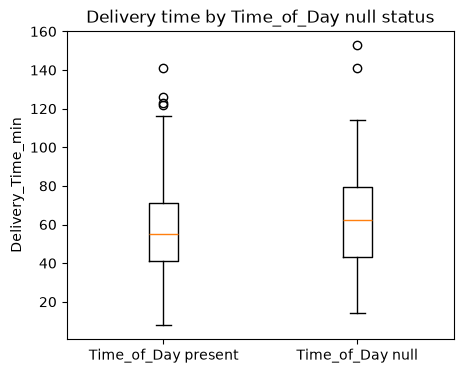

In [13]:
fig, ax = plt.subplots(figsize=(5, 4))
ax.boxplot(
    [df.loc[df[col].notnull(), "Delivery_Time_min"], df.loc[df[col].isnull(), "Delivery_Time_min"]],
    tick_labels=[f"{col} present", f"{col} null"],
)
ax.set_ylabel("Delivery_Time_min")
ax.set_title(f"Delivery time by {col} null status")
plt.show()

In [14]:
pd.DataFrame({
    "null_rate_by_Weather": df.groupby("Weather")[col].apply(lambda s: s.isnull().mean()),
}).round(3), pd.DataFrame({
    "null_rate_by_Traffic_Level": df.groupby("Traffic_Level")[col].apply(lambda s: s.isnull().mean()),
}).round(3)

(         null_rate_by_Weather
 Weather                      
 Clear                   0.030
 Foggy                   0.019
 Rainy                   0.020
 Snowy                   0.031
 Windy                   0.062,
                null_rate_by_Traffic_Level
 Traffic_Level                            
 High                                0.020
 Low                                 0.042
 Medium                              0.023)

**Classification: MAR.** This is the clearest signal of the four: rows with a null `Time_of_Day` average 66.2 min vs. 56.4 min for the rest (a ~10 min gap), and their spread is also much wider (std ~33.7 vs ~21.6) — the null group skews toward slow, high-variance deliveries. Two candidates support this: `Weather` shows `Windy` at a 6.2% null rate vs. 2-3% for the other conditions, and `Traffic_Level` shows `Low` at 4.2% vs. 2.0-2.3% for `Medium`/`High`. Missingness here tracks observed variables (weather, traffic, and the target itself) rather than looking random.

### `Courier_Experience_yrs`

In [15]:
col = "Courier_Experience_yrs"
df.groupby(df[col].isnull())["Delivery_Time_min"].agg(["mean", "median", "std", "count"])

,mean,median,std,count
Courier_Experience_yrs,,,,
False,56.743299,56.0,22.071352,970
True,56.366667,53.5,22.430711,30


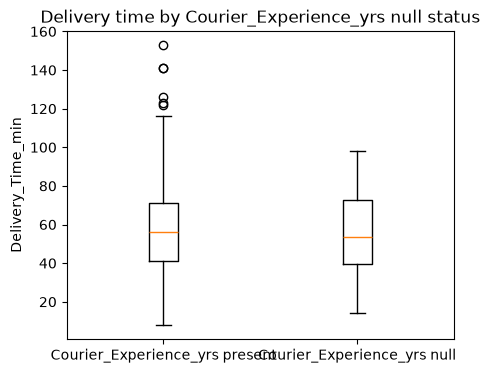

In [16]:
fig, ax = plt.subplots(figsize=(5, 4))
ax.boxplot(
    [df.loc[df[col].notnull(), "Delivery_Time_min"], df.loc[df[col].isnull(), "Delivery_Time_min"]],
    tick_labels=[f"{col} present", f"{col} null"],
)
ax.set_ylabel("Delivery_Time_min")
ax.set_title(f"Delivery time by {col} null status")
plt.show()

In [17]:
pd.DataFrame({
    "null_rate_by_Vehicle_Type": df.groupby("Vehicle_Type")[col].apply(lambda s: s.isnull().mean()),
}).round(3), pd.DataFrame({
    "null_rate_by_Weather": df.groupby("Weather")[col].apply(lambda s: s.isnull().mean()),
}).round(3)

(              null_rate_by_Vehicle_Type
 Vehicle_Type                           
 Bike                              0.030
 Car                               0.015
 Scooter                           0.040,
          null_rate_by_Weather
 Weather                      
 Clear                   0.032
 Foggy                   0.019
 Rainy                   0.029
 Snowy                   0.052
 Windy                   0.010)

**Classification: MCAR.** `Delivery_Time_min` is virtually the same whether `Courier_Experience_yrs` is null or not (56.4 vs. 56.7 min). `Vehicle_Type` shows some spread (`Car` 1.5% vs. `Scooter` 4.0%) and `Weather` too (`Windy` 1.0% vs. `Snowy` 5.2%), but neither is consistent with the other or with the target, which looks more like noise across small null counts per category than a real pattern. A plausible business story exists (experience not yet recorded for brand-new couriers) but nothing in the observed data confirms or contradicts it — nothing here supports MAR or MNAR over MCAR.

### Step C summary

In [18]:
pd.DataFrame([
    {
        "column": "Weather",
        "classification": "MCAR",
        "justification": "No target gap (54.2 vs 56.8 min) and no consistent split across Traffic_Level or Vehicle_Type.",
    },
    {
        "column": "Traffic_Level",
        "classification": "MAR (leaning)",
        "justification": "Target gap (62.1 vs 56.6 min) plus null rate doubling Bike->Scooter (2.0% -> 4.3%).",
    },
    {
        "column": "Time_of_Day",
        "classification": "MAR",
        "justification": "Largest target gap (66.2 vs 56.4 min, wider spread) and higher null rate under Windy weather and Low traffic.",
    },
    {
        "column": "Courier_Experience_yrs",
        "classification": "MCAR",
        "justification": "No target gap (56.4 vs 56.7 min); category-level spread looks like noise, not a consistent pattern.",
    },
])

,column,classification,justification
0,Weather,MCAR,No target gap (54.2 vs 56.8 min) and no consis...
1,Traffic_Level,MAR (leaning),Target gap (62.1 vs 56.6 min) plus null rate d...
2,Time_of_Day,MAR,"Largest target gap (66.2 vs 56.4 min, wider sp..."
3,Courier_Experience_yrs,MCAR,No target gap (56.4 vs 56.7 min); category-lev...


## Step D: numeric distributions

Histograms and skew for `Distance_km`, `Preparation_Time_min`, `Courier_Experience_yrs`, and the target `Delivery_Time_min`. `.dropna()` is used only inside the plotting call, so the null values these columns have (`Courier_Experience_yrs`) are excluded from that one histogram without touching `df` itself.

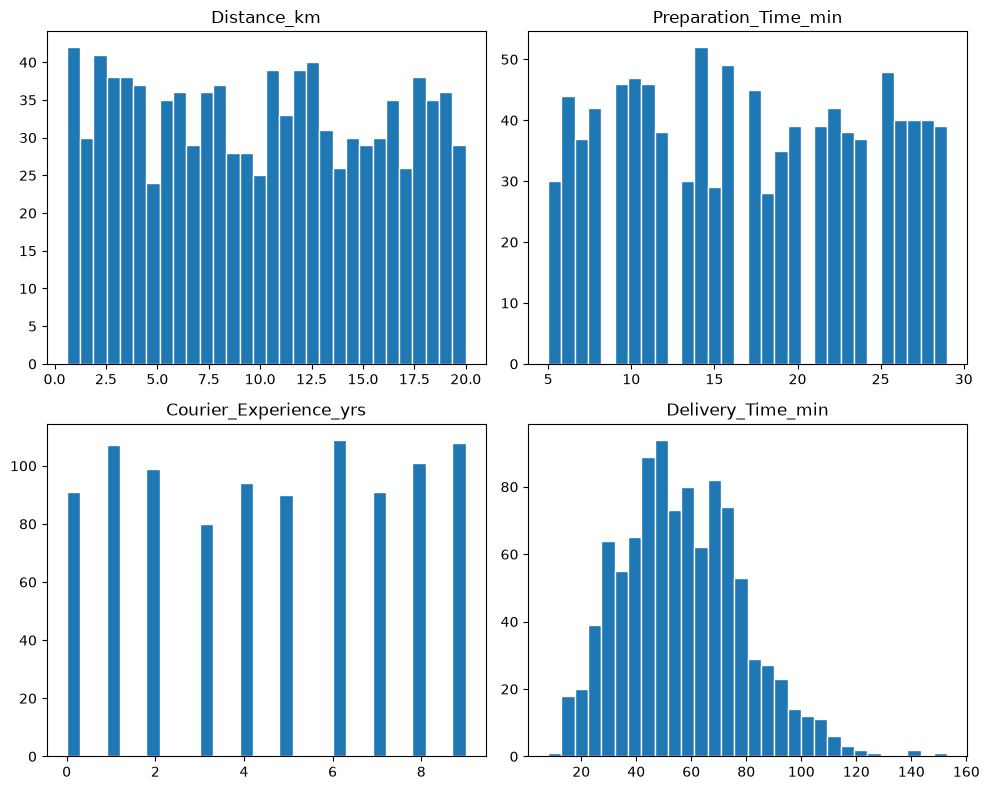

,skew
Distance_km,0.039
Preparation_Time_min,0.030
Courier_Experience_yrs,-0.029
Delivery_Time_min,0.507


In [19]:
num_cols = ["Distance_km", "Preparation_Time_min", "Courier_Experience_yrs", "Delivery_Time_min"]

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
for ax, c in zip(axes.flat, num_cols):
    ax.hist(df[c].dropna(), bins=30, edgecolor="white")
    ax.set_title(c)
plt.tight_layout()
plt.show()

df[num_cols].skew().round(3).rename("skew").to_frame()

`Distance_km` (skew ≈ 0.04), `Preparation_Time_min` (≈ 0.03), and `Courier_Experience_yrs` (≈ -0.03) are all close enough to 0 to call symmetric — the histograms look roughly uniform/flat rather than bell-shaped, but there is no meaningful directional skew to correct for any of them. `Delivery_Time_min` is the one exception at ≈ 0.51 (moderate right skew): its mean (56.7) sits noticeably above its median (55.5), with a longer tail toward slower deliveries. That lines up with the 6 IQR outliers found for it below.

## Step E: categorical frequencies

Bar chart per column for `Weather`, `Traffic_Level`, `Time_of_Day`, and `Vehicle_Type`. `.fillna("Missing")` is applied only inside a throwaway `Series` built for each plot's counts, so nulls show up as their own bar without changing `df`.

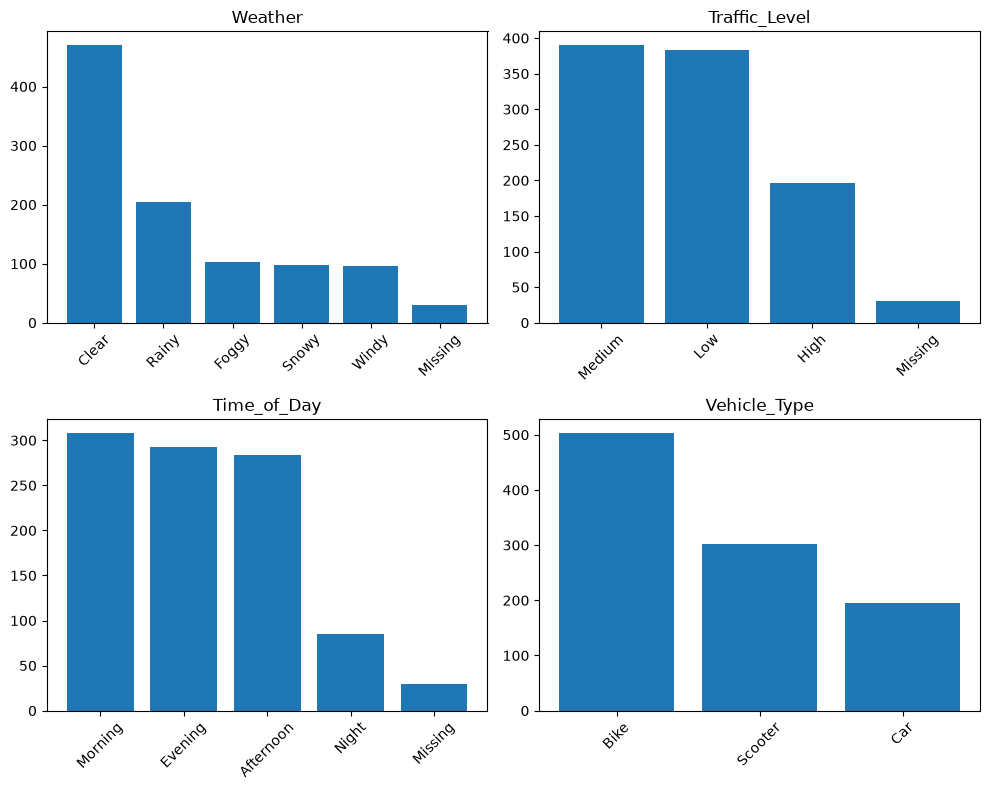

In [20]:
cat_cols = ["Weather", "Traffic_Level", "Time_of_Day", "Vehicle_Type"]

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
for ax, c in zip(axes.flat, cat_cols):
    counts = df[c].fillna("Missing").value_counts()
    ax.bar(counts.index, counts.values)
    ax.set_title(c)
    ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

`Weather` is dominated by `Clear` (470/1000); the other four conditions each sit in the 96-204 range, with the 30 `Missing` roughly in line with the smaller categories. `Traffic_Level` is fairly balanced between `Medium` (390) and `Low` (383), with `High` smaller (197). `Time_of_Day` is balanced across `Morning`/`Evening`/`Afternoon` (~284-308 each) but `Night` is notably smaller (85) — worth keeping in mind later, since any `Night`-specific effect will be estimated from less data. `Vehicle_Type` has no nulls and is led by `Bike` (503), then `Scooter` (302) and `Car` (195).

## Step F: outlier detection (IQR method)

For `Distance_km`, `Preparation_Time_min`, and `Delivery_Time_min`: `Q1 - 1.5×IQR` and `Q3 + 1.5×IQR` as bounds, counting values outside them. Reported only — nothing is removed or capped here.

In [21]:
outlier_cols = ["Distance_km", "Preparation_Time_min", "Delivery_Time_min"]

iqr_rows = []
for c in outlier_cols:
    q1 = df[c].quantile(0.25)
    q3 = df[c].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    n_outliers = ((df[c] < lower) | (df[c] > upper)).sum()
    iqr_rows.append({
        "column": c, "Q1": q1, "Q3": q3, "IQR": iqr,
        "lower_bound": round(lower, 2), "upper_bound": round(upper, 2),
        "n_outliers": n_outliers,
    })

iqr_summary = pd.DataFrame(iqr_rows)
iqr_summary

,column,Q1,Q3,IQR,lower_bound,upper_bound,n_outliers
0,Distance_km,5.105,15.0175,9.9125,-9.76,29.89,0
1,Preparation_Time_min,11.000,23.0000,12.0000,-7.00,41.00,0
2,Delivery_Time_min,41.000,71.0000,30.0000,-4.00,116.00,6


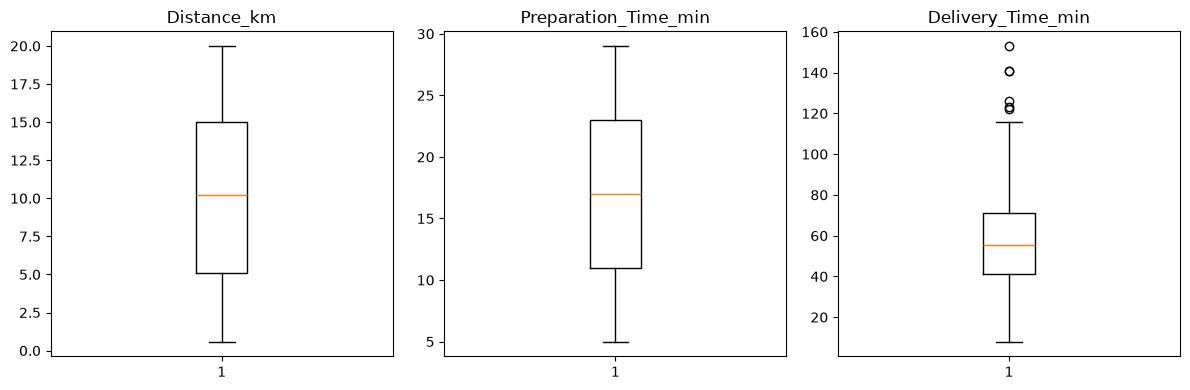

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, c in zip(axes, outlier_cols):
    ax.boxplot(df[c].dropna())
    ax.set_title(c)
plt.tight_layout()
plt.show()

`Distance_km` and `Preparation_Time_min` have **0 IQR outliers** each — consistent with their near-zero skew, their whole range sits inside the 1.5×IQR fence. `Delivery_Time_min` has **6 outliers**, all above the upper bound (~116 min) — the same long right tail already visible in its histogram and its positive skew. These are reported only; whether to treat them as errors, keep them, or cap them is a decision for later, once bivariate analysis shows whether they correspond to plausible combinations of the other variables (e.g. long distance + bad weather + high traffic) or look more like data issues.

## Step 4: bivariate — categorical variables vs. target

For each categorical column: a boxplot of `Delivery_Time_min` by category (ordered by mean, high to low), and the mean/median/std/count table behind it. Rows where the column is null are simply excluded from that column's grouping by `groupby`/boxplot construction — `df` itself is untouched.

### `Weather`

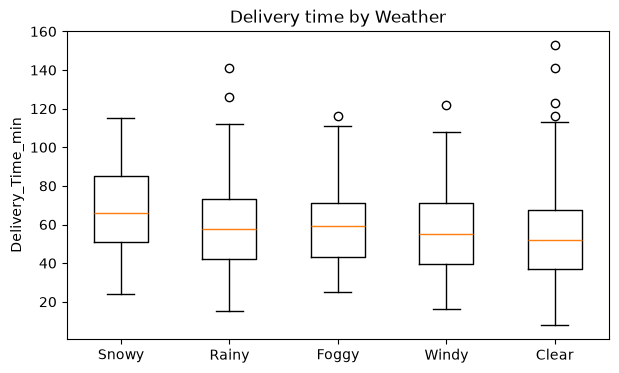

,mean,median,std,count
Weather,,,,
Snowy,67.11,66.0,21.29,97
Rainy,59.79,57.5,22.82,204
Foggy,59.47,59.0,20.86,103
Windy,55.46,55.0,21.78,96
Clear,53.08,52.0,21.27,470


In [23]:
col = "Weather"
order = df.groupby(col)["Delivery_Time_min"].mean().sort_values(ascending=False).index

fig, ax = plt.subplots(figsize=(7, 4))
ax.boxplot([df.loc[df[col] == cat, "Delivery_Time_min"] for cat in order], tick_labels=order)
ax.set_ylabel("Delivery_Time_min")
ax.set_title(f"Delivery time by {col}")
plt.show()

df.groupby(col)["Delivery_Time_min"].agg(["mean", "median", "std", "count"]).round(2).loc[order]

**`Weather` shows the clearest gap of the four categoricals.** `Snowy` has the highest average delivery time at **67.11 min**, vs. **53.08 min** for `Clear` — a **~14.0 min** difference, the largest of any single category against the baseline. `Rainy` is also elevated at **59.79 min** (~6.7 min above `Clear`), and `Foggy` is close behind at 59.47 min. `Windy` (55.46 min) sits much closer to `Clear`. So the notable condition here is specifically **`Snowy`**, with `Rainy` and `Foggy` as secondary, smaller effects — worth keeping this exact number (`Snowy`: +14.0 min vs. `Clear`) for the strategic reflections later.

### `Traffic_Level`

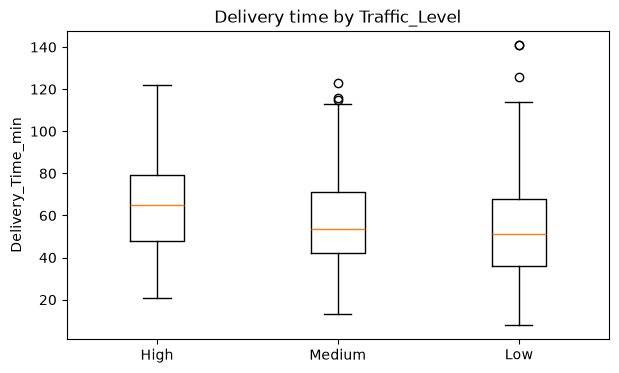

,mean,median,std,count
Traffic_Level,,,,
High,64.81,65.0,21.87,197
Medium,56.02,53.5,21.19,390
Low,52.89,51.0,21.68,383


In [24]:
col = "Traffic_Level"
order = df.groupby(col)["Delivery_Time_min"].mean().sort_values(ascending=False).index

fig, ax = plt.subplots(figsize=(7, 4))
ax.boxplot([df.loc[df[col] == cat, "Delivery_Time_min"] for cat in order], tick_labels=order)
ax.set_ylabel("Delivery_Time_min")
ax.set_title(f"Delivery time by {col}")
plt.show()

df.groupby(col)["Delivery_Time_min"].agg(["mean", "median", "std", "count"]).round(2).loc[order]

Also a clear, ordered gradient: `High` (64.81 min) > `Medium` (56.02 min) > `Low` (52.89 min) — an ~11.9 min spread from lowest to highest, the second-largest categorical effect after `Weather`.

### `Time_of_Day`

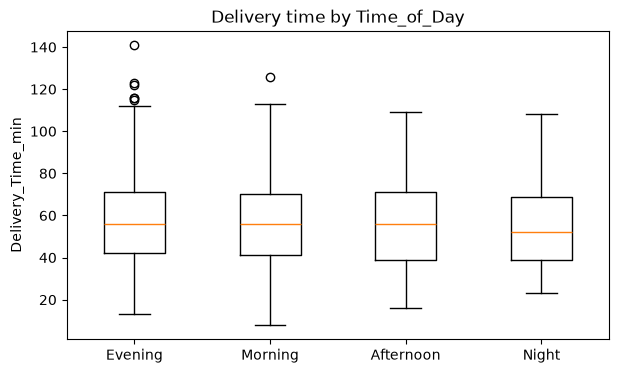

,mean,median,std,count
Time_of_Day,,,,
Evening,57.48,56.0,22.18,293
Morning,56.12,56.0,21.54,308
Afternoon,56.08,56.0,21.09,284
Night,55.21,52.0,21.43,85


In [25]:
col = "Time_of_Day"
order = df.groupby(col)["Delivery_Time_min"].mean().sort_values(ascending=False).index

fig, ax = plt.subplots(figsize=(7, 4))
ax.boxplot([df.loc[df[col] == cat, "Delivery_Time_min"] for cat in order], tick_labels=order)
ax.set_ylabel("Delivery_Time_min")
ax.set_title(f"Delivery time by {col}")
plt.show()

df.groupby(col)["Delivery_Time_min"].agg(["mean", "median", "std", "count"]).round(2).loc[order]

No notable differences: all four means sit within a ~2.3 min band (55.21-57.48), much smaller than the spread from `Weather` or `Traffic_Level`. `Time_of_Day` does not look like a strong driver of delivery time on its own.

### `Vehicle_Type`

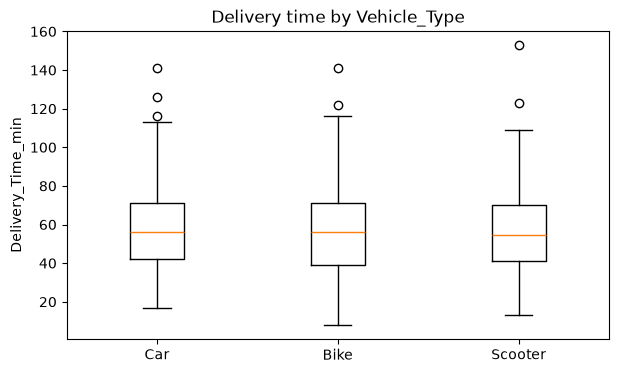

,mean,median,std,count
Vehicle_Type,,,,
Car,58.20,56.0,22.52,195
Bike,56.57,56.0,22.19,503
Scooter,56.05,54.5,21.60,302


In [26]:
col = "Vehicle_Type"
order = df.groupby(col)["Delivery_Time_min"].mean().sort_values(ascending=False).index

fig, ax = plt.subplots(figsize=(7, 4))
ax.boxplot([df.loc[df[col] == cat, "Delivery_Time_min"] for cat in order], tick_labels=order)
ax.set_ylabel("Delivery_Time_min")
ax.set_title(f"Delivery time by {col}")
plt.show()

df.groupby(col)["Delivery_Time_min"].agg(["mean", "median", "std", "count"]).round(2).loc[order]

Also no notable differences: `Car` (58.20 min), `Bike` (56.57 min), and `Scooter` (56.05 min) are within ~2.2 min of each other. `Vehicle_Type` does not look like a strong driver either.

## Step 5: correlation matrix (numeric variables + target)

Pearson correlation between `Distance_km`, `Preparation_Time_min`, `Courier_Experience_yrs`, and `Delivery_Time_min`, shown as a heatmap (built with `matplotlib` directly — no extra library needed for a single quick heatmap).

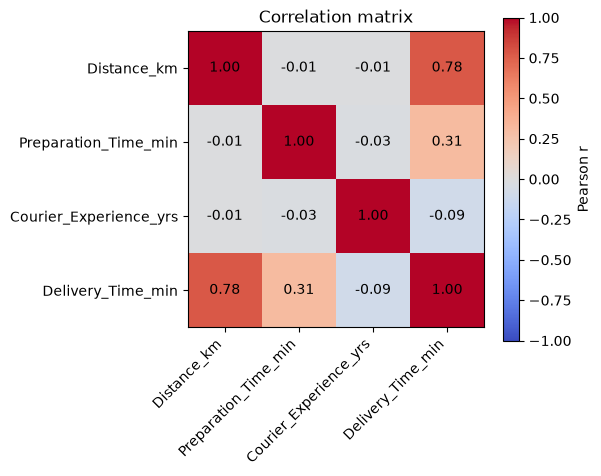

,Distance_km,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
Distance_km,1.000,-0.009,-0.008,0.781
Preparation_Time_min,-0.009,1.000,-0.031,0.307
Courier_Experience_yrs,-0.008,-0.031,1.000,-0.090
Delivery_Time_min,0.781,0.307,-0.090,1.000


In [27]:
corr_cols = ["Distance_km", "Preparation_Time_min", "Courier_Experience_yrs", "Delivery_Time_min"]
corr = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(corr, vmin=-1, vmax=1, cmap="coolwarm")
ax.set_xticks(range(len(corr_cols)))
ax.set_xticklabels(corr_cols, rotation=45, ha="right")
ax.set_yticks(range(len(corr_cols)))
ax.set_yticklabels(corr_cols)
for i in range(len(corr_cols)):
    for j in range(len(corr_cols)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center")
fig.colorbar(im, ax=ax, label="Pearson r")
ax.set_title("Correlation matrix")
plt.tight_layout()
plt.show()

corr.round(3)

`Distance_km` correlates strongly with `Delivery_Time_min` (r ≈ 0.78) — by far the strongest relationship in the dataset. `Preparation_Time_min` has a moderate positive correlation (r ≈ 0.31). `Courier_Experience_yrs` has a weak negative correlation (r ≈ -0.09) — more experienced couriers trend very slightly faster, but the effect is small. The three features are essentially uncorrelated with each other (|r| ≤ 0.03), so there is no multicollinearity concern among them going into modeling.